# Lesson 3.1 — Turbulence Basics

## The Cigarette Smoke Analogy

Watch cigarette smoke rise from a lit cigarette in a still room. Initially it rises in a
smooth, laminar thread. Then, a few centimetres up, it suddenly breaks into chaotic,
swirling eddies — turbulence. You can watch the transition happen in real time.

Turbulence is characterised by:
- **Irregularity**: chaotic, unpredictable velocity fluctuations
- **Diffusivity**: enhanced mixing of momentum, heat, mass
- **Vorticity**: three-dimensional vortex structures at many scales
- **Dissipation**: kinetic energy converted to heat by viscosity
- **High Re**: turbulence requires convection >> viscous damping

---

## Reynolds Decomposition

Osborne Reynolds (1895) proposed splitting any turbulent quantity into a **mean** and a
**fluctuation**:

$$u = \bar{u} + u', \qquad p = \bar{p} + p'$$

where $\bar{u} = \langle u \rangle$ is the time-average and $u'$ is the fluctuation with $\bar{u'} = 0$.

---

## The Reynolds-Averaged Navier-Stokes (RANS) Equations

Substitute the decomposition into N-S and take the time average:

$$\frac{\partial \bar{u}_i}{\partial t} + \bar{u}_j \frac{\partial \bar{u}_i}{\partial x_j} = -\frac{1}{\rho}\frac{\partial \bar{p}}{\partial x_i} + \nu \frac{\partial^2 \bar{u}_i}{\partial x_j \partial x_j} - \frac{\partial \overline{u'_i u'_j}}{\partial x_j}$$

The new term $-\overline{u'_i u'_j}$ is the **Reynolds stress tensor** — it represents the
average momentum flux due to turbulent fluctuations.

---

## The Closure Problem

We now have 4 equations (RANS continuity + 3 momentum) but 10 unknowns
($\bar{u}$, $\bar{p}$, plus 6 independent Reynolds stress components). The system is
**unclosed** — there are more unknowns than equations.

Deriving transport equations for $\overline{u'_i u'_j}$ introduces triple correlations
$\overline{u'_i u'_j u'_k}$. The hierarchy never closes — this is the **turbulence closure problem**.

Every turbulence model is an engineering approximation to close this system.

---

## The Boussinesq Eddy-Viscosity Hypothesis

The most common closure: model the Reynolds stresses analogously to viscous stresses:

$$-\overline{u'_i u'_j} = \nu_t \left(\frac{\partial \bar{u}_i}{\partial x_j} + \frac{\partial \bar{u}_j}{\partial x_i}\right) - \frac{2}{3}k \delta_{ij}$$

where $\nu_t$ is the **turbulent (eddy) viscosity** and $k = \frac{1}{2}\overline{u'_i u'_i}$
is the **turbulent kinetic energy**.

The challenge: $\nu_t$ is not a fluid property — it depends on the local flow state.
Turbulence models provide equations for $\nu_t$.

---

## The Energy Cascade

Richardson (1922): *"Big whirls have little whirls that feed on their velocity, and little
whirls have lesser whirls, and so on to viscosity."*

Kolmogorov (1941) made this precise:

- **Energy injection scale** $L$: large eddies driven by mean flow
- **Inertial range**: energy cascades from large to small eddies; $E(k) \sim k^{-5/3}$
- **Kolmogorov scale** $\eta = (\nu^3/\varepsilon)^{1/4}$: smallest eddies where viscosity dissipates energy

The ratio $L/\eta \sim Re^{3/4}$. For a turbulent pipe at Re = $10^6$: $L/\eta \sim 10^{4.5}$.
Directly resolving all scales (DNS) requires $(L/\eta)^3 \sim 10^{13.5}$ grid points — impossible.


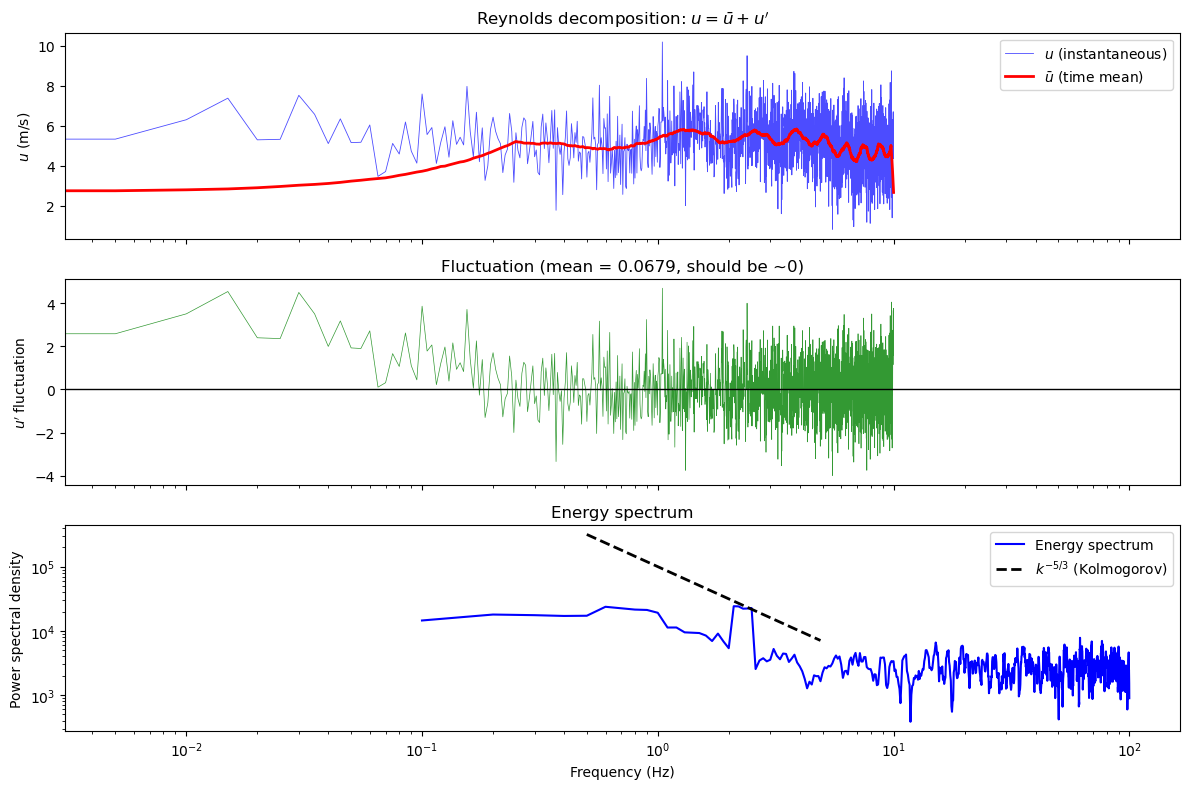

Turbulence intensity: 25.2%
Mean of fluctuation: 0.067926  (should be ~0)
Mean of signal: 5.054


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate Reynolds decomposition on a synthetic turbulent signal
np.random.seed(42)
t = np.linspace(0, 10, 2000)

# Synthetic turbulent signal: mean + large-scale + small-scale fluctuations
u_mean  = 5.0 + 0.5*np.sin(2*np.pi*t/10)   # slow mean variation
u_turb  = (1.2*np.random.randn(2000)
           + 0.5*np.sin(2*np.pi*t*0.8 + 1.2)
           + 0.3*np.sin(2*np.pi*t*2.3))     # turbulent fluctuations
u_signal = u_mean + u_turb

# Time-average (running mean over a window)
window = 100
u_bar = np.convolve(u_signal, np.ones(window)/window, mode='same')
u_prime = u_signal - u_bar

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, u_signal, 'b-', linewidth=0.6, alpha=0.7, label='$u$ (instantaneous)')
axes[0].plot(t, u_bar, 'r-', linewidth=2, label='$\\bar{u}$ (time mean)')
axes[0].set_ylabel('$u$ (m/s)')
axes[0].set_title('Reynolds decomposition: $u = \\bar{u} + u\' $')
axes[0].legend()

axes[1].plot(t, u_prime, 'g-', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_ylabel("$u'$ fluctuation")
axes[1].set_title(f"Fluctuation (mean = {u_prime.mean():.4f}, should be ~0)")

# Turbulent kinetic energy spectrum
freq = np.fft.rfftfreq(len(u_prime), d=t[1]-t[0])
spec = np.abs(np.fft.rfft(u_prime))**2
spec_smooth = np.convolve(spec, np.ones(5)/5, mode='same')

axes[2].loglog(freq[1:], spec_smooth[1:], 'b-', linewidth=1.5, label='Energy spectrum')
# Kolmogorov -5/3 slope
k_ref = freq[5:50]
axes[2].loglog(k_ref, 1e5 * k_ref**(-5/3), 'k--', linewidth=2, label='$k^{-5/3}$ (Kolmogorov)')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power spectral density')
axes[2].set_title('Energy spectrum')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Turbulence intensity: {u_prime.std()/u_bar.mean()*100:.1f}%")
print(f"Mean of fluctuation: {u_prime.mean():.6f}  (should be ~0)")
print(f"Mean of signal: {u_signal.mean():.3f}")

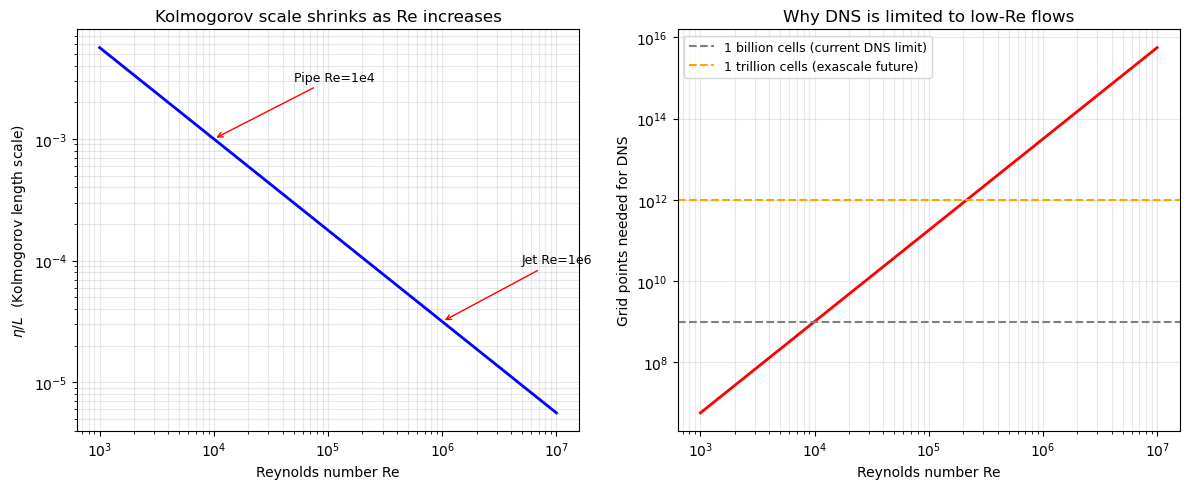

Re = 1e+04: DNS needs ~1.0e+09 cells
Re = 1e+06: DNS needs ~3.2e+13 cells
Re = 1e+08: DNS needs ~1.0e+18 cells


In [2]:
# Kolmogorov scales: show how resolution requirements scale with Re

Re_values = np.logspace(3, 7, 100)

# Number of grid points required for DNS in 3D: (L/eta)^3 ~ Re^(9/4)
N_dns_3d = Re_values**(9/4)

# Kolmogorov length scale: eta/L ~ Re^(-3/4)
eta_ratio = Re_values**(-3/4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(Re_values, eta_ratio, 'b-', linewidth=2)
axes[0].set_xlabel('Reynolds number Re')
axes[0].set_ylabel('$\\eta / L$  (Kolmogorov length scale)')
axes[0].set_title('Kolmogorov scale shrinks as Re increases')
axes[0].grid(True, which='both', alpha=0.3)
# Annotate some examples
examples = [(1e4, 'Pipe Re=1e4'), (1e6, 'Jet Re=1e6')]
for Re_ex, label in examples:
    axes[0].annotate(label, xy=(Re_ex, Re_ex**(-3/4)),
                     xytext=(Re_ex*5, Re_ex**(-3/4)*3),
                     arrowprops=dict(arrowstyle='->', color='red'), fontsize=9)

axes[1].loglog(Re_values, N_dns_3d, 'r-', linewidth=2)
axes[1].axhline(1e9, color='gray', linestyle='--', label='1 billion cells (current DNS limit)')
axes[1].axhline(1e12, color='orange', linestyle='--', label='1 trillion cells (exascale future)')
axes[1].set_xlabel('Reynolds number Re')
axes[1].set_ylabel('Grid points needed for DNS')
axes[1].set_title('Why DNS is limited to low-Re flows')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

for Re_ex in [1e4, 1e6, 1e8]:
    print(f"Re = {Re_ex:.0e}: DNS needs ~{Re_ex**(9/4):.1e} cells")

## Three Approaches to Turbulent Flow

| Approach | Full name | What is resolved | Cost | When to use |
|----------|-----------|-----------------|------|-------------|
| DNS | Direct Numerical Simulation | Everything down to $\eta$ | Extreme | Research, Re $< 10^4$ |
| LES | Large Eddy Simulation | Large eddies; model small | High | Complex geometry, high Re |
| RANS | Reynolds-Averaged N-S | Only mean flow; model all turbulence | Low | Engineering, Re any |

Industrial CFD uses RANS 95% of the time. LES is growing. DNS is research-only.

## Key Takeaways

- Turbulence is chaotic, 3D, multi-scale, and dissipative.
- Reynolds decomposition: $u = \bar{u} + u'$. RANS equations govern the mean flow.
- Reynolds stresses $-\overline{u'_i u'_j}$ are the unknown — the closure problem.
- Boussinesq: model Reynolds stresses as $\nu_t \times$ mean strain rate.
- DNS is impossible at high Re — turbulence models (RANS/LES) are necessary.

---

**Next**: Lesson 3.2 — Turbulence Models: Spalart-Allmaras, $k$-$\varepsilon$, $k$-$\omega$ SST.
